In [2]:
import os
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
from dataclasses import dataclass

@dataclass
class Config:
    data_dir:Path =  Path('data')
    train_dir:Path = data_dir/"train"
    test_dir:Path = data_dir/"test"
    val_ratio: float= 0.2

    model_name: str = "resnet18"
    img_size: int = 224
    batch_size: int = 32
    epochs: int = 10
    lr: float = 1e-4
    seed: int = 42

    num_workers: int = 4
    use_cuda: bool = True

In [4]:
cfg = Config()
random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

Images per label:
Ac: 201
As: 168
Cb: 222
Cc: 248
Ci: 119
Cs: 267
Ct: 180
Cu: 162
Ns: 254
Sc: 320
St: 182

Total images in train: 2323


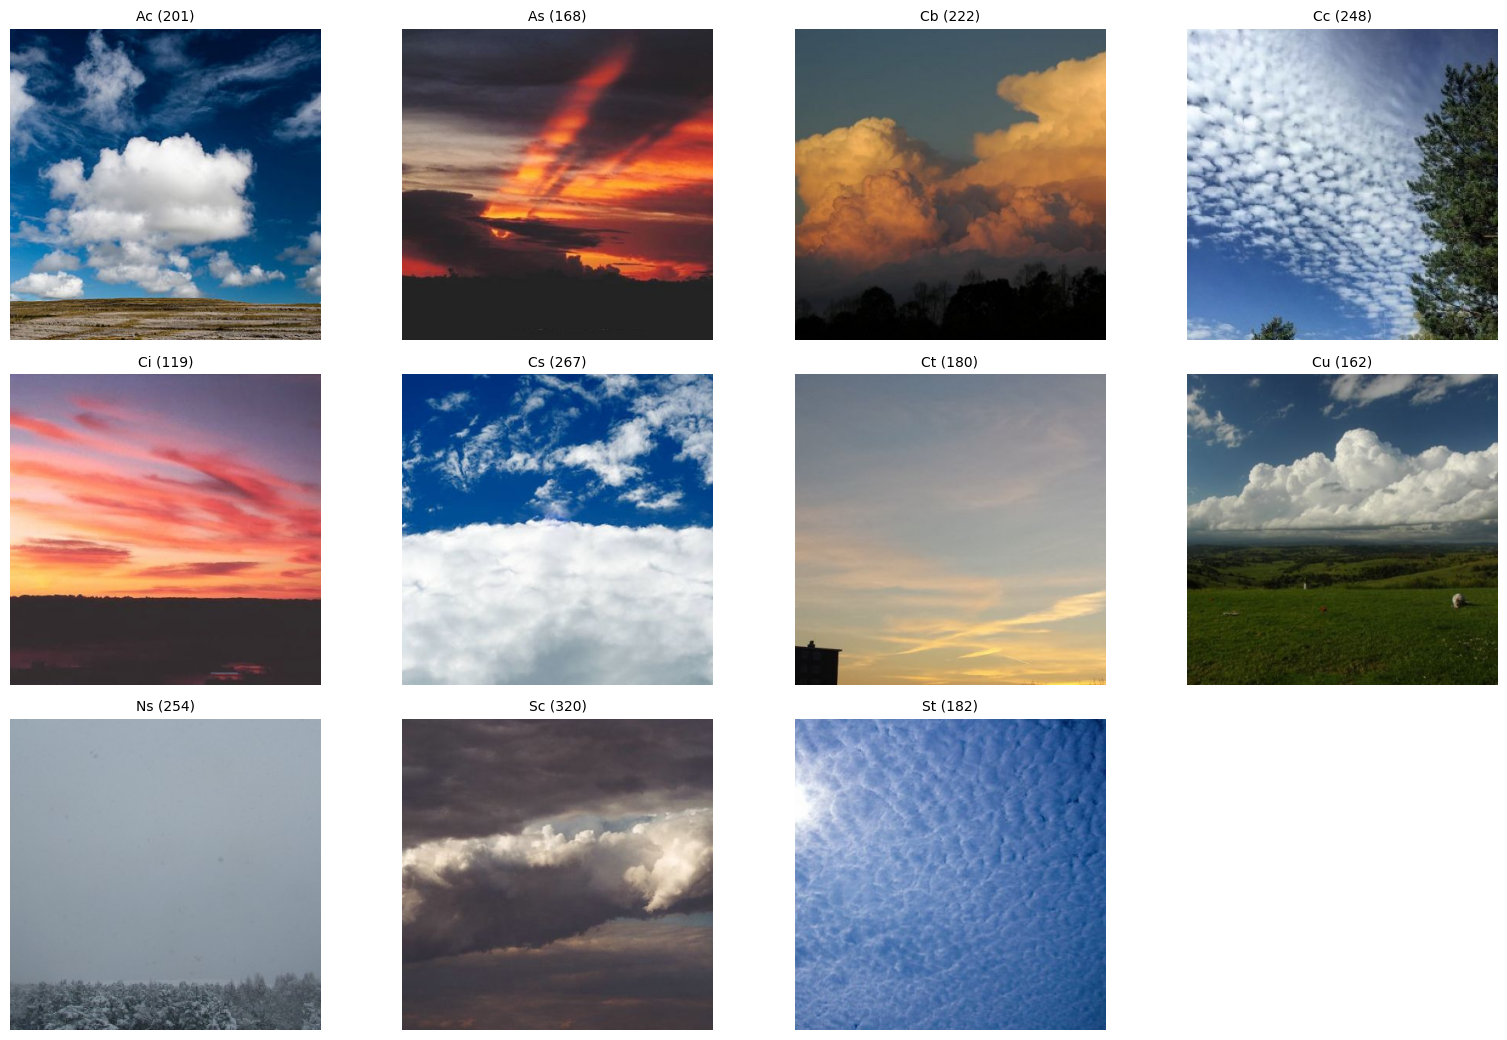

In [5]:
#the subfolders are labels
classes = sorted([d.name for d in cfg.train_dir.iterdir() if d.is_dir()])
if not classes:
    raise ValueError(f"No Classes Found in {cfg.train_dir}")

def is_jpeg(p:Path) -> bool:
    return p.suffix.lower() in {'.jpg', '.jpeg', '.png'}

def iter_jpeg(folder: Path):
    for root, _, files in os.walk(folder):
        for f in files:
            p = Path(root) / f
            if is_jpeg(p):
                yield p

#count items per label and sample one
counts = {}
samples = {}

for cls in classes:
    files = sorted(list(iter_jpeg(cfg.train_dir/ cls)))
    counts[cls] = len(files)
    if not files:
        print(f"no Jpegs found in {cls}")
        continue
    else:
        samples[cls] = random.choice(files)
    
#print counts
print("Images per label:")
total = sum(counts.values())
for cls in classes:
    print(f"{cls}: {counts.get(cls,0)}")
print(f"\nTotal images in train: {total}")

n = len(samples)
if n == 0:
    print("No samples :(")
else:
    cols = min(4,n)
    rows = (n + cols - 1)//cols
    plt.figure(figsize = (cols * 4, rows * 3.5))
    for i, cls in enumerate(sorted(samples.keys())):
        img_path = samples[cls]
        img = Image.open(img_path).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"{cls} ({counts.get(cls,0)})", fontsize = 10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
from torch.utils.data import random_split


train_transforms  = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_train_set = datasets.ImageFolder(cfg.train_dir, transform = train_transforms)

#split train into val and train
val_size = int(cfg.val_ratio * len(full_train_set))
train_size = len(full_train_set) - val_size
train_ds, val_ds = random_split(full_train_set, [train_size, val_size])

#dataloaders for the dataset
train_loader = DataLoader(train_ds, batch_size = cfg.batch_size, shuffle = True, num_workers=cfg.num_workers, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size = cfg.batch_size, shuffle = False, num_workers=cfg.num_workers, pin_memory=True)


In [7]:
class_names = full_train_set.classes
print("Classes", class_names)

Classes ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']


In [8]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

model = models.resnet18(pretrained = True)

#replace final layer with a classifier for the cloud set
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))
model = model.to(device)

c:\Users\Jomar\VSCode\ML\BasicML\ML\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Jomar\VSCode\ML\BasicML\ML\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
#loss and optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = cfg.lr)

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs = cfg.epochs):
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)


        #eval model
        model.eval()
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

    print("Training complete. Best Val Acc: {:.4f}".format(best_val_acc))
    
    return model

In [12]:
model = train_model(model, train_loader, val_loader, criterion, optimizer, cfg.epochs)


Epoch 1/10 - Train Loss: 1.7823, Train Acc: 0.3954, Val Acc: 0.4677
Epoch 2/10 - Train Loss: 1.1216, Train Acc: 0.6331, Val Acc: 0.4914
Epoch 3/10 - Train Loss: 0.7882, Train Acc: 0.7569, Val Acc: 0.4957
Epoch 4/10 - Train Loss: 0.5524, Train Acc: 0.8499, Val Acc: 0.4914
Epoch 5/10 - Train Loss: 0.3873, Train Acc: 0.9005, Val Acc: 0.4978
Epoch 6/10 - Train Loss: 0.3005, Train Acc: 0.9242, Val Acc: 0.5129
Epoch 7/10 - Train Loss: 0.2630, Train Acc: 0.9344, Val Acc: 0.5022
Epoch 8/10 - Train Loss: 0.1931, Train Acc: 0.9527, Val Acc: 0.5129
Epoch 9/10 - Train Loss: 0.1897, Train Acc: 0.9500, Val Acc: 0.5302
Epoch 10/10 - Train Loss: 0.1977, Train Acc: 0.9489, Val Acc: 0.4935
Training complete. Best Val Acc: 0.5302
